In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from mlxtend.plotting import plot_decision_regions

In [50]:
df = pd.DataFrame()

In [51]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [52]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


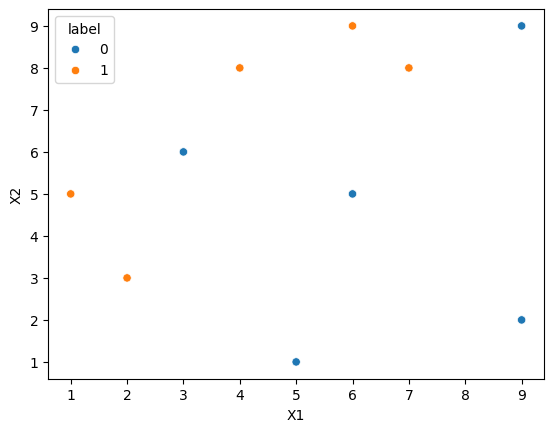

In [53]:
sns.scatterplot(data=df, x="X1", y="X2",hue='label')
plt.show()

In [54]:
df.shape

(10, 3)

In [55]:
df['weights'] = 1/df.shape[0]

In [56]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [59]:
x= df.iloc[:,0:2].values
x

array([[1, 5],
       [2, 3],
       [3, 6],
       [4, 8],
       [5, 1],
       [6, 9],
       [6, 5],
       [7, 8],
       [9, 9],
       [9, 2]], dtype=int64)

In [60]:
y=df.iloc[:,2].values
y

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0], dtype=int64)

In [61]:
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

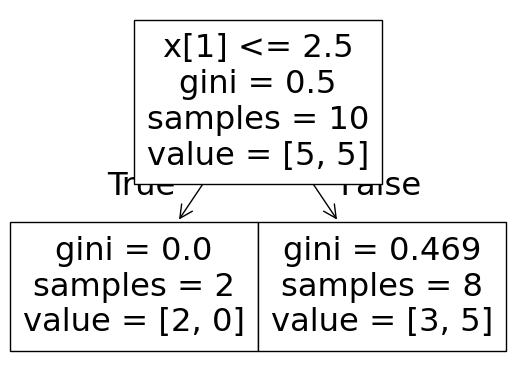

In [62]:
from sklearn.tree import plot_tree
plot_tree(dt1)

In [ ]:
# the deciosn tree split on column 1 x[1]<=2.5

<Axes: >

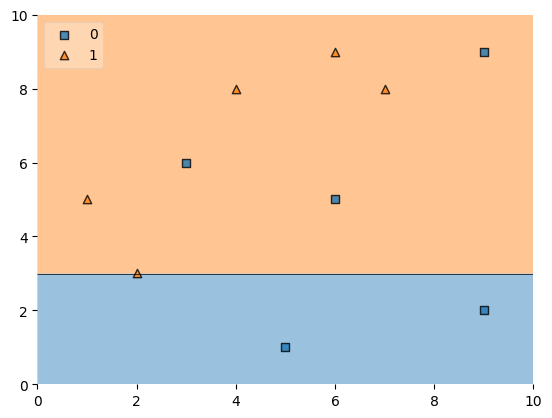

In [64]:
plot_decision_regions(x,y,clf =dt1 ,legend=2)

In [65]:
#the above is the decsion boundry 
#we can check the perfromance of the dataset and ho w much errors it does
# 0's are corretcly classifies but 1's are not
# it is doing 3 mistakes, 3 blue points are in orange region

In [66]:
#prediction on training data
df['y_pred'] = dt1.predict(x)

In [67]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [68]:
# model makes 3 mistakes rows (2,6,8)

In [69]:
#now calculate weights
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error))

In [70]:
# calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

0.42364893019360184

In [71]:
#Update weights
def update_row_weights(row, alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] *np.exp(-alpha)
    else:
        return row['weights'] *np.exp(alpha)

In [72]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [73]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [74]:
df['updated_weights'].sum()

0.9165153319682015

In [75]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [76]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [77]:
df['normalized_weights'].sum()

1.0

In [78]:
#now create range

In [79]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [80]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [81]:
df[['X1','X2','label','weights','y_pred','updated_weights','normalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.071475,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.166559,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.071475,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.071475,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.166559,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.071475,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.166559,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,0.928525,1.000000


In [82]:
# now create 10 new random numbers 

In [83]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [84]:

index_values = create_new_dataset(df)

index_values

[9, 6, 1, 0, 2, 5, 5, 4, 8, 2]

In [85]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [86]:
second_df

,X1,X2,label,weights
9,9,2,0,0.1
6,6,5,0,0.1
1,2,3,1,0.1
0,1,5,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
4,5,1,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1


In [ ]:
#so if u see we have got those rows more whre there were more mistakes (2,6,8)
#this is upsampling

In [88]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [89]:
x= second_df.iloc[:,0:2].values
y= second_df.iloc[:,2].values

In [90]:
dt2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.625, 0.5, '  False')]

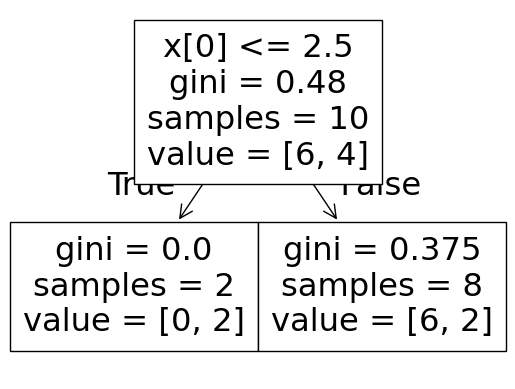

In [91]:
plot_tree(dt2)

<Axes: >

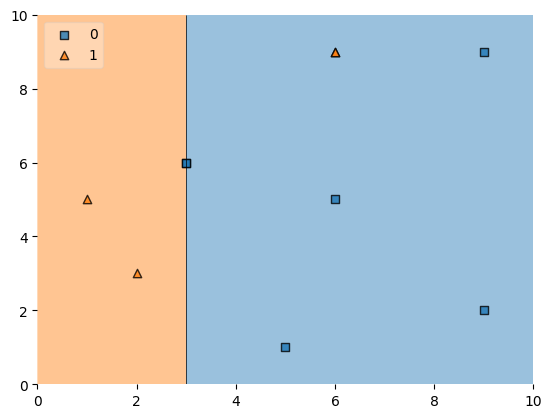

In [93]:
plot_decision_regions(x,y,clf=dt2, legend =2)

In [94]:
#now here we can see, it crrectly classified the blue points
# it but is makaing one mistake only orange point is in blue region

In [95]:
second_df['y_pred'] = dt2.predict(x)

In [96]:
second_df

,X1,X2,label,weights,y_pred
9,9,2,0,0.1,0
6,6,5,0,0.1,0
1,2,3,1,0.1,1
0,1,5,1,0.1,1
2,3,6,0,0.1,0
5,6,9,1,0.1,0
5,6,9,1,0.1,0
4,5,1,0,0.1,0
8,9,9,0,0.1,0
2,3,6,0,0.1,0


In [97]:
alpha2 = calculate_model_weight(0.2)
alpha2

0.6931471805599453

In [98]:
def update_row_weights(row,alpha=0.69):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [99]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [100]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
9,9,2,0,0.1,0,0.050158
6,6,5,0,0.1,0,0.050158
1,2,3,1,0.1,1,0.050158
0,1,5,1,0.1,1,0.050158
2,3,6,0,0.1,0,0.050158
5,6,9,1,0.1,0,0.199372
5,6,9,1,0.1,0,0.199372
4,5,1,0,0.1,0,0.050158
8,9,9,0,0.1,0,0.050158
2,3,6,0,0.1,0,0.050158


In [101]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [102]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
9,9,2,0,0.1,0,0.050158,0.062697
6,6,5,0,0.1,0,0.050158,0.062697
1,2,3,1,0.1,1,0.050158,0.062697
0,1,5,1,0.1,1,0.050158,0.062697
2,3,6,0,0.1,0,0.050158,0.062697
5,6,9,1,0.1,0,0.199372,0.249213
5,6,9,1,0.1,0,0.199372,0.249213
4,5,1,0,0.1,0,0.050158,0.062697
8,9,9,0,0.1,0,0.050158,0.062697
2,3,6,0,0.1,0,0.050158,0.062697


In [103]:

second_df['nomalized_weights'].sum()

1.0

In [104]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [105]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [106]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
9,9,2,0,0.1,0,0.062697,0.000000,0.062697
6,6,5,0,0.1,0,0.062697,0.062697,0.125393
1,2,3,1,0.1,1,0.062697,0.125393,0.188090
0,1,5,1,0.1,1,0.062697,0.188090,0.250787
2,3,6,0,0.1,0,0.062697,0.250787,0.313483
5,6,9,1,0.1,0,0.249213,0.313483,0.562697
5,6,9,1,0.1,0,0.249213,0.562697,0.811910
4,5,1,0,0.1,0,0.062697,0.811910,0.874607
8,9,9,0,0.1,0,0.062697,0.874607,0.937303
2,3,6,0,0.1,0,0.062697,0.937303,1.000000


In [107]:
index_values = create_new_dataset(second_df)

In [108]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [109]:
third_df

,X1,X2,label,weights
2,3,6,0,0.1
6,6,5,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
5,6,9,1,0.1
2,3,6,0,0.1
6,6,5,0,0.1
5,6,9,1,0.1
9,9,2,0,0.1
5,6,9,1,0.1


In [110]:

dt3 = DecisionTreeClassifier(max_depth=1)

x = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(x,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

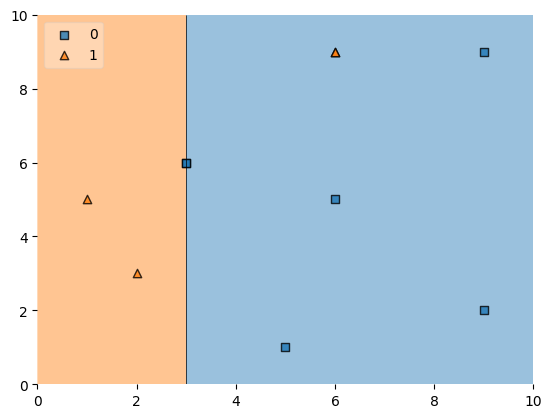

In [112]:

plot_decision_regions(x, y, clf=dt3, legend=2)

In [114]:

third_df['y_pred'] = dt3.predict(x)

In [115]:
third_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,1
8,9,9,0,0.1,1
5,6,9,1,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
5,6,9,1,0.1,0
9,9,2,0,0.1,0
5,6,9,1,0.1,0


In [116]:

alpha3 = calculate_model_weight(0.3)
alpha3

0.42364893019360184

In [117]:

print(alpha1,alpha2,alpha3)

0.42364893019360184 0.6931471805599453 0.42364893019360184


In [118]:
#prediction

In [119]:

query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1], dtype=int64)

In [120]:
dt2.predict(query)

array([1], dtype=int64)

In [121]:

dt3.predict(query)

array([1], dtype=int64)

In [122]:

alpha1*1 + alpha2*(1) + alpha3*(1)

1.5404450409471488

In [123]:
np.sign(1.54)

1.0

In [124]:

query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1], dtype=int64)

In [125]:

dt2.predict(query)

array([0], dtype=int64)

In [126]:

dt3.predict(query)

array([0], dtype=int64)

In [127]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

-0.6931471805599453

In [128]:
np.sign(-0.69)

-1.0